Setup complete.


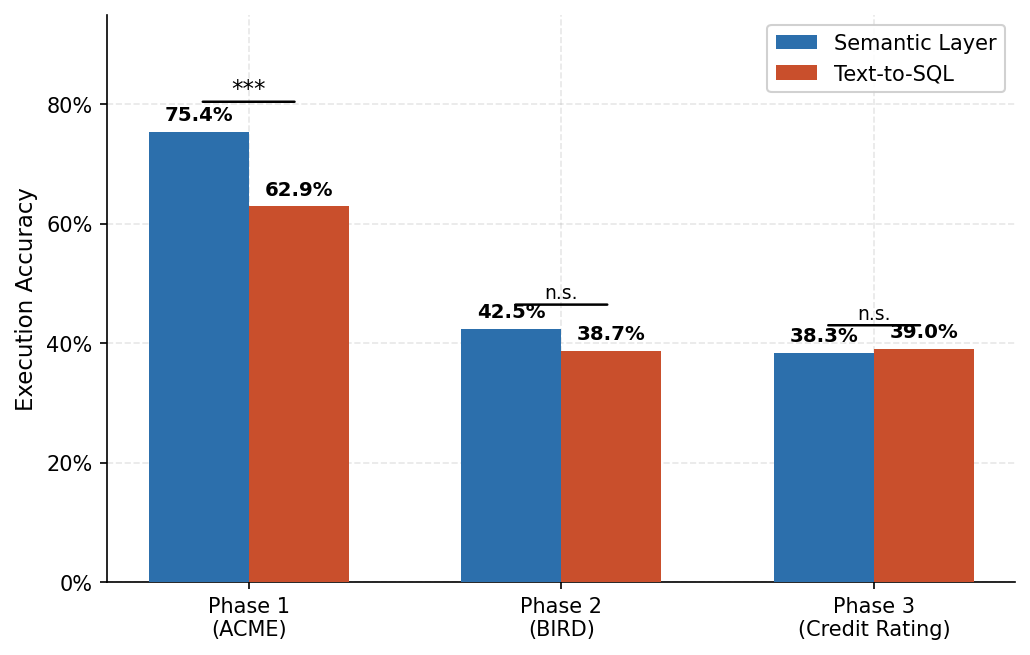

Saved: figure1_overall_accuracy.png


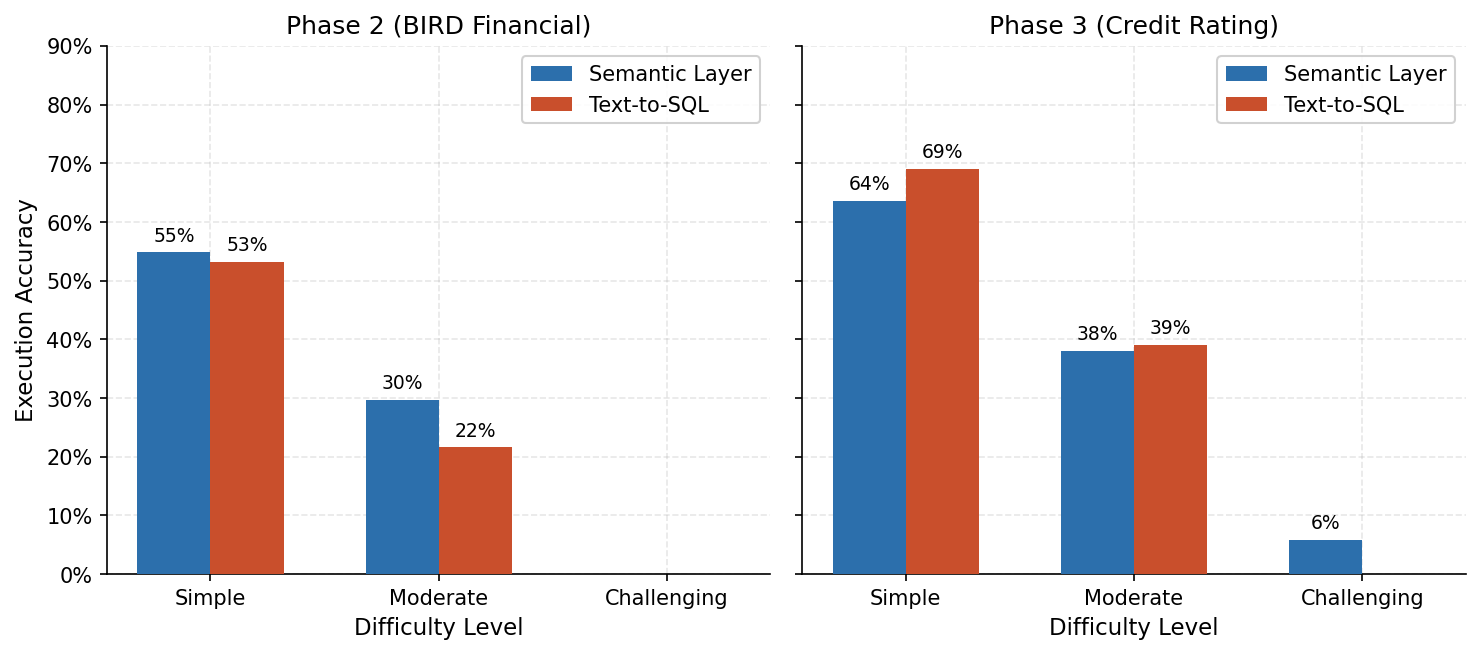

Saved: figure2_difficulty_accuracy.png


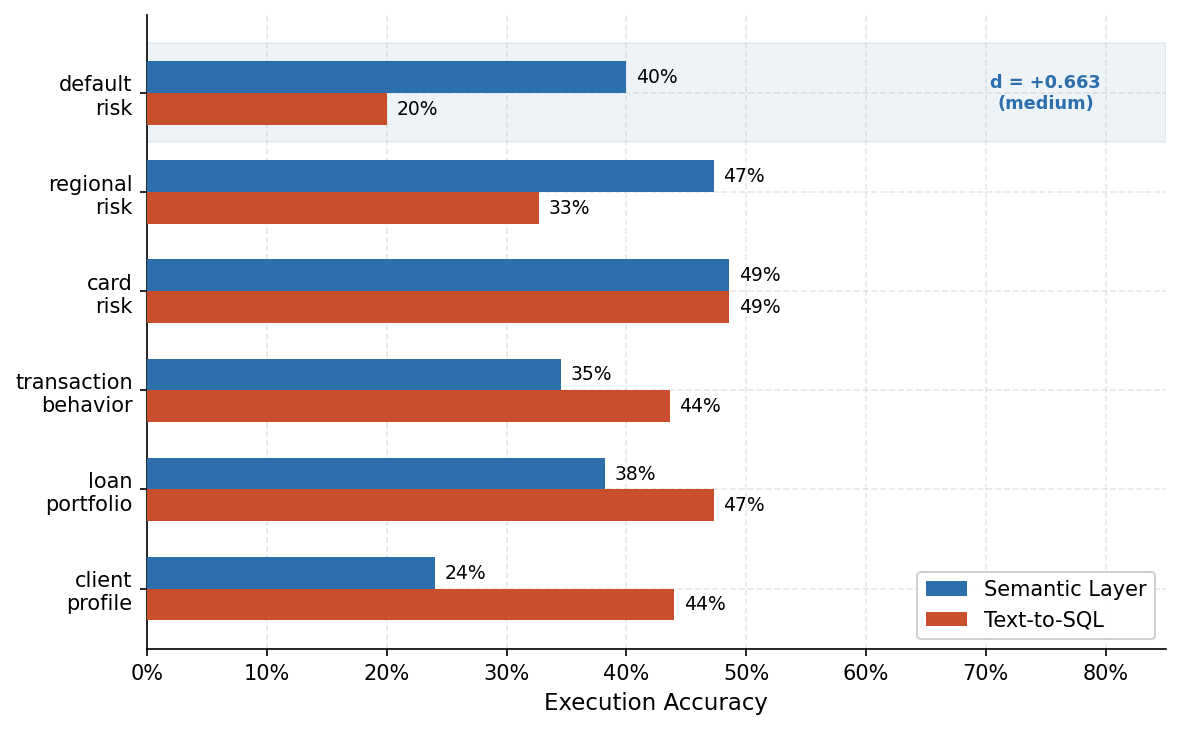

Saved: figure3_category_accuracy.png


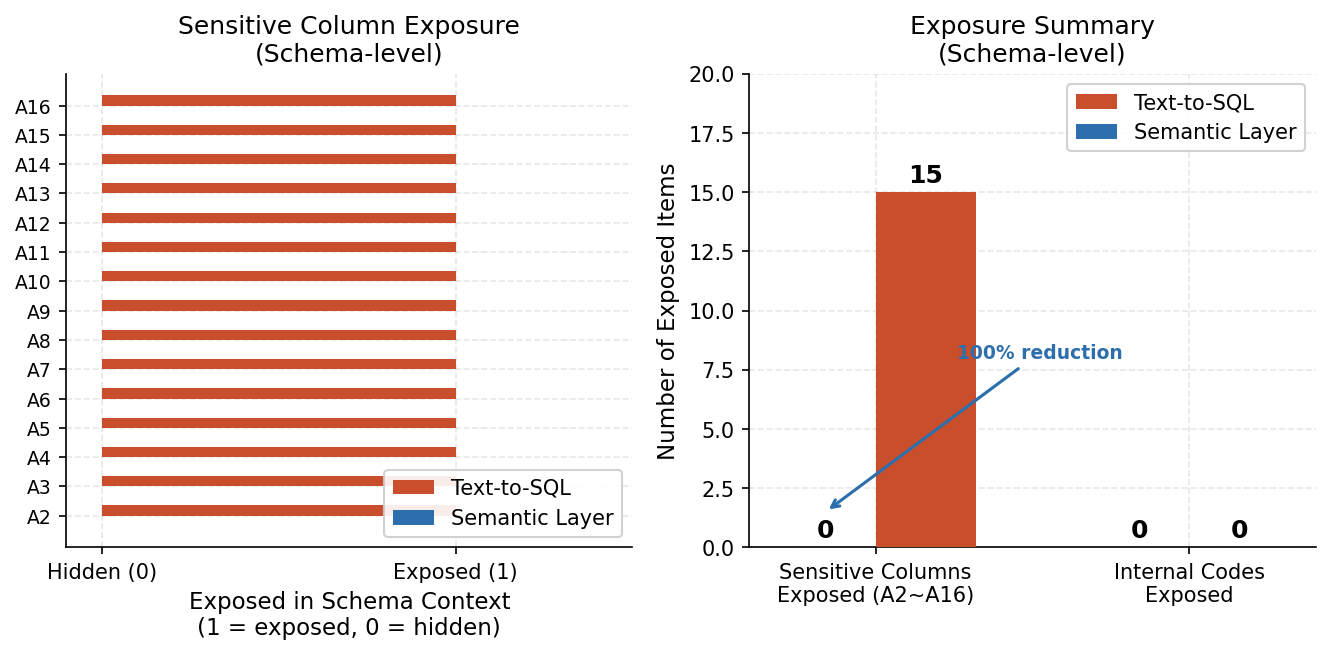

Saved: figure4_exposure.png


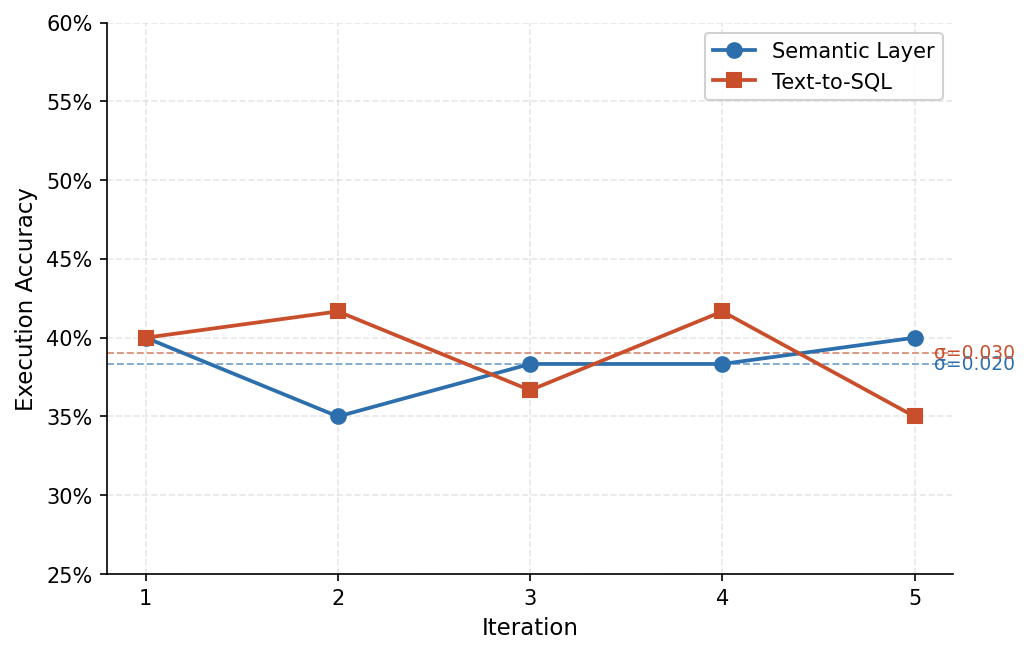

Saved: figure5_iteration_stability.png
Saved figures:
  figure1_overall_accuracy.png  (220 KB)
  figure2_difficulty_accuracy.png  (325 KB)
  figure3_category_accuracy.png  (282 KB)
  figure4_exposure.png  (416 KB)
  figure5_iteration_stability.png  (262 KB)


In [2]:
# ============================================================
# paper_figures.ipynb
# Publication-quality Figures for Paper
# Author  : [Your Name]
# Date    : 2026-05-14
# DPI     : 600
# Format  : PNG
# ============================================================


# %% [markdown]
# ## 0. Libraries and Style Configuration

# %%
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Publication style settings
matplotlib.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'axes.linewidth'   : 0.8,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'figure.dpi'       : 150,   # preview DPI (save at 600)
})

# Color palette
C_SL  = '#2C6FAC'   # Semantic Layer — blue
C_SQL = '#C94F2C'   # Text-to-SQL    — red-orange
C_SL_L  = '#7AAFD4' # light blue
C_SQL_L = '#E8967A' # light red-orange

DPI_SAVE = 600

# Load data
df_p2 = pd.read_csv("./results_phase2_bird_v2.csv")
df_p3 = pd.read_csv("./results_phase3_v2.csv")

print("Setup complete.")


# %% [markdown]
# ## Figure 1 — Overall Accuracy Comparison (All Phases)

# %%
fig, ax = plt.subplots(figsize=(7, 4.5))

phases   = ['Phase 1\n(ACME)', 'Phase 2\n(BIRD)', 'Phase 3\n(Credit Rating)']
sl_vals  = [0.754,
            df_p2[df_p2['method']=='semantic_layer']['is_correct'].mean(),
            df_p3[df_p3['method']=='semantic_layer']['is_correct'].mean()]
sql_vals = [0.629,
            df_p2[df_p2['method']=='text_to_sql']['is_correct'].mean(),
            df_p3[df_p3['method']=='text_to_sql']['is_correct'].mean()]

x = np.arange(len(phases))
w = 0.32

b_sl  = ax.bar(x - w/2, sl_vals,  w, label='Semantic Layer', color=C_SL,  zorder=3)
b_sql = ax.bar(x + w/2, sql_vals, w, label='Text-to-SQL',    color=C_SQL, zorder=3)

# Value labels
for bar in list(b_sl) + list(b_sql):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.012,
            f'{bar.get_height():.1%}',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# Significance annotation — Phase 1
ax.annotate('', xy=(x[0]+w/2, sl_vals[0]+0.05),
            xytext=(x[0]-w/2, sl_vals[0]+0.05),
            arrowprops=dict(arrowstyle='-', color='black', lw=1.2))
ax.text(x[0], sl_vals[0]+0.06, '***', ha='center', fontsize=11)

# n.s. annotation — Phase 2 & 3
for idx in [1, 2]:
    top = max(sl_vals[idx], sql_vals[idx]) + 0.04
    ax.annotate('', xy=(x[idx]+w/2, top),
                xytext=(x[idx]-w/2, top),
                arrowprops=dict(arrowstyle='-', color='black', lw=1.2))
    ax.text(x[idx], top+0.01, 'n.s.', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(phases)
ax.set_ylabel('Execution Accuracy')
ax.set_ylim(0, 0.95)
ax.set_yticks(np.arange(0, 0.9, 0.2))
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('figure1_overall_accuracy.png', dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
print("Saved: figure1_overall_accuracy.png")


# %% [markdown]
# ## Figure 2 — Accuracy by Difficulty (Jagged Frontier)

# %%
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

diffs       = ['Simple', 'Moderate', 'Challenging']
diffs_lower = ['simple', 'moderate', 'challenging']
x = np.arange(len(diffs))
w = 0.32

for ax, (phase, df) in zip(axes, [("Phase 2 (BIRD Financial)", df_p2),
                                    ("Phase 3 (Credit Rating)",  df_p3)]):
    sl_v  = [df[(df['method']=='semantic_layer') &
                (df['difficulty']==d)]['is_correct'].mean() for d in diffs_lower]
    sql_v = [df[(df['method']=='text_to_sql') &
                (df['difficulty']==d)]['is_correct'].mean() for d in diffs_lower]

    b_sl  = ax.bar(x - w/2, sl_v,  w, label='Semantic Layer', color=C_SL,  zorder=3)
    b_sql = ax.bar(x + w/2, sql_v, w, label='Text-to-SQL',    color=C_SQL, zorder=3)

    for bar in list(b_sl) + list(b_sql):
        if bar.get_height() > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.012,
                    f'{bar.get_height():.0%}',
                    ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(diffs)
    ax.set_title(phase)
    ax.set_xlabel('Difficulty Level')
    ax.legend(loc='upper right', framealpha=0.9)
    ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))

axes[0].set_ylabel('Execution Accuracy')
axes[0].set_ylim(0, 0.90)

plt.tight_layout()
plt.savefig('figure2_difficulty_accuracy.png', dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
print("Saved: figure2_difficulty_accuracy.png")


# %% [markdown]
# ## Figure 3 — Accuracy by Category (Phase 3)

# %%
by_cat = df_p3.groupby(['category','method'])['is_correct'].mean().unstack()

# Sort by SL advantage
by_cat['diff'] = by_cat['semantic_layer'] - by_cat['text_to_sql']
by_cat = by_cat.sort_values('diff', ascending=True)

categories = [c.replace('_', '\n') for c in by_cat.index]
sl_v  = by_cat['semantic_layer'].values
sql_v = by_cat['text_to_sql'].values
y     = np.arange(len(categories))
h     = 0.32

fig, ax = plt.subplots(figsize=(8, 5))

b_sl  = ax.barh(y + h/2, sl_v,  h, label='Semantic Layer', color=C_SL,  zorder=3)
b_sql = ax.barh(y - h/2, sql_v, h, label='Text-to-SQL',    color=C_SQL, zorder=3)

for bar in list(b_sl) + list(b_sql):
    if bar.get_width() > 0.01:
        ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.0%}',
                ha='left', va='center', fontsize=9)

# Highlight default_risk
default_idx = list(by_cat.index).index('default_risk')
ax.axhspan(default_idx - 0.5, default_idx + 0.5,
           alpha=0.08, color=C_SL, zorder=0)
ax.text(0.75, default_idx, 'd = +0.663\n(medium)',
        ha='center', va='center', fontsize=8.5,
        color=C_SL, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(categories)
ax.set_xlabel('Execution Accuracy')
ax.set_xlim(0, 0.85)
ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('figure3_category_accuracy.png', dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
print("Saved: figure3_category_accuracy.png")


# %% [markdown]
# ## Figure 4 — Sensitive Information Exposure (RQ2)

# %%
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

# Left: column exposure count
ax1 = axes[0]
items  = ['A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','A15','A16']
sql_exp = [1] * 15
sl_exp  = [0] * 15
y = np.arange(len(items))
h = 0.35

ax1.barh(y + h/2, sql_exp, h, label='Text-to-SQL',    color=C_SQL, zorder=3)
ax1.barh(y - h/2, sl_exp,  h, label='Semantic Layer', color=C_SL,  zorder=3)
ax1.set_yticks(y)
ax1.set_yticklabels(items, fontsize=9)
ax1.set_xlabel('Exposed in Schema Context\n(1 = exposed, 0 = hidden)')
ax1.set_xlim(-0.1, 1.5)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Hidden (0)', 'Exposed (1)'])
ax1.legend(loc='lower right', framealpha=0.9)
ax1.set_title('Sensitive Column Exposure\n(Schema-level)')

# Right: summary bar
ax2 = axes[1]
metrics  = ['Sensitive Columns\nExposed (A2~A16)', 'Internal Codes\nExposed']
sql_vals = [15, 0]
sl_vals  = [0,  0]
x2 = np.arange(len(metrics))
w2 = 0.32

b_sql = ax2.bar(x2 + w2/2, sql_vals, w2, label='Text-to-SQL',    color=C_SQL, zorder=3)
b_sl  = ax2.bar(x2 - w2/2, sl_vals,  w2, label='Semantic Layer', color=C_SL,  zorder=3)

for bar in list(b_sql) + list(b_sl):
    val = int(bar.get_height())
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             str(val), ha='center', va='bottom',
             fontsize=12, fontweight='bold')

# 100% reduction annotation
ax2.annotate('100% reduction', xy=(x2[0]-w2/2, 1.5),
             xytext=(x2[0]+w2/2+0.1, 8),
             arrowprops=dict(arrowstyle='->', color=C_SL, lw=1.5),
             fontsize=9, color=C_SL, fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels(metrics)
ax2.set_ylabel('Number of Exposed Items')
ax2.set_ylim(0, 20)
ax2.legend(loc='upper right', framealpha=0.9)
ax2.set_title('Exposure Summary\n(Schema-level)')

plt.tight_layout()
plt.savefig('figure4_exposure.png', dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
print("Saved: figure4_exposure.png")


# %% [markdown]
# ## Figure 5 — Iteration Stability (Phase 3)

# %%
by_iter = df_p3.groupby(['iteration','method'])['is_correct'].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(by_iter.index + 1, by_iter['semantic_layer'],
        marker='o', markersize=7, linewidth=1.8,
        label='Semantic Layer', color=C_SL, zorder=3)
ax.plot(by_iter.index + 1, by_iter['text_to_sql'],
        marker='s', markersize=7, linewidth=1.8,
        label='Text-to-SQL', color=C_SQL, zorder=3)

# Shaded std band
sl_std  = by_iter['semantic_layer'].std()
sql_std = by_iter['text_to_sql'].std()
sl_mean = by_iter['semantic_layer'].mean()
sql_mean= by_iter['text_to_sql'].mean()

ax.axhline(sl_mean,  color=C_SL,  linestyle='--', linewidth=0.9, alpha=0.6)
ax.axhline(sql_mean, color=C_SQL, linestyle='--', linewidth=0.9, alpha=0.6)

# Std annotation
ax.text(5.1, sl_mean,  f'σ={sl_std:.3f}',  color=C_SL,  fontsize=9, va='center')
ax.text(5.1, sql_mean, f'σ={sql_std:.3f}', color=C_SQL, fontsize=9, va='center')

ax.set_xlabel('Iteration')
ax.set_ylabel('Execution Accuracy')
ax.set_xticks(range(1, 6))
ax.set_ylim(0.25, 0.60)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('figure5_iteration_stability.png', dpi=DPI_SAVE, bbox_inches='tight')
plt.show()
print("Saved: figure5_iteration_stability.png")


# %% [markdown]
# ## All Figures Saved

# %%
import os
figures = [f for f in os.listdir('.') if f.startswith('figure') and f.endswith('.png')]
print("Saved figures:")
for f in sorted(figures):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f}  ({size_kb:.0f} KB)")